# PRCP-1013: Walk vs Run Activity Classification
### Complete Data Analysis Report & Predictive Modeling

**Objective:** Build a machine learning classification model to predict whether a person is **walking (0)** or **running (1)** based on raw wrist-worn motion sensor readings.

**Tasks:**
- **Task 1:** Complete data analysis report on the given data
- **Task 2:** Predictive model to classify walking vs running + key influencing features
- **Model Comparison Report:** Performance of multiple classifiers + production recommendation
- **Challenges Report:** Data challenges and techniques used with reasoning

**Dataset:** 88,588 sensor readings | 7 predictors | Binary classification target (`activity`)
**Target:** `activity` — 0 = Walking, 1 = Running

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Libraries loaded successfully!")

Libraries loaded successfully!


### Load and Understand the Dataset

The dataset contains motion sensor readings from a wrist-worn device recorded while
one participant (viktor) performed walking and running activities.

| Column | Type | Description |
|---|---|---|
| `date` | Object | Date of recording — not predictive |
| `time` | Object | Timestamp — not predictive |
| `username` | Object | Participant name (only "viktor") — zero variance |
| `wrist` | Int | Sensor wrist location: 0 = left, 1 = right |
| `activity` | **Int** | **Target**: 0 = Walk, 1 = Run |
| `acceleration_x/y/z` | Float | Linear acceleration in 3 axes (g-force units) |
| `gyro_x/y/z` | Float | Angular velocity in 3 axes (rad/s) |

In [2]:
df = pd.read_csv('walkrun.csv')
print(f"Dataset shape : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(df['activity'].value_counts().rename(index={0:'Walk (0)', 1:'Run (1)'}).to_string())
print(f"\nClass balance  : {df['activity'].value_counts(normalize=True).mul(100).round(1).to_dict()}")

Dataset shape : 88,588 rows  x  11 columns
Memory usage  : 20.7 MB
Missing values: 0

Class distribution:
activity
Run (1)     44365
Walk (0)    44223

Class balance  : {1: 50.1, 0: 49.9}


In [3]:
df.head()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,30/06/2017,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,30/06/2017,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,30/06/2017,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,30/06/2017,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,30/06/2017,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [4]:
df.describe()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,0.522170,0.500801,-0.074811,-0.562585,-0.313956,0.004160,0.037203,0.022327
std,0.499511,0.500002,1.009299,0.658458,0.486815,1.253423,1.198725,1.914423
min,0.000000,0.000000,-5.350500,-3.299000,-3.753800,-4.430600,-7.464700,-9.480000
25%,0.000000,0.000000,-0.381800,-1.033500,-0.376000,-0.920700,-0.644825,-1.345125
50%,1.000000,1.000000,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,1.000000,1.000000,0.355500,-0.241775,-0.085900,0.888800,0.733700,1.398200
max,1.000000,1.000000,5.603300,2.668000,1.640300,4.874200,8.498000,11.266200


### Exploratory Data Analysis (EDA)

#### Basic Dataset Overview

In [5]:
print("\n" + "="*55)
print("  DATASET OVERVIEW")
print("="*55)

# Display the first few rows to understand the data structure
print("\nFirst 5 rows:")
print(df.head())

# Data types for each column
print("\nData Types:")
print(df.dtypes)

# Summary statistics for numerical columns
print("\nStatistical Summary:")
print(df.describe())


  DATASET OVERVIEW

First 5 rows:
         date                time username  wrist  activity  acceleration_x  \
0  30/06/2017  13:51:15:847724020   viktor      0         0          0.2650   
1  30/06/2017  13:51:16:246945023   viktor      0         0          0.6722   
2  30/06/2017  13:51:16:446233987   viktor      0         0          0.4399   
3  30/06/2017  13:51:16:646117985   viktor      0         0          0.3031   
4  30/06/2017  13:51:16:846738994   viktor      0         0          0.4814   

   acceleration_y  acceleration_z  gyro_x  gyro_y  gyro_z  
0         -0.7814         -0.0076 -0.0590  0.0325 -2.9296  
1         -1.1233         -0.2344 -0.1757  0.0208  0.1269  
2         -1.4817          0.0722 -0.9105  0.1063 -2.4367  
3         -0.8125          0.0888  0.1199 -0.4099 -2.9336  
4         -0.9312          0.0359  0.0527  0.4379  2.4922  

Data Types:
date               object
time               object
username           object
wrist               int64
activity     

#### Missing Value/Null Value Analysis

In [6]:
# Calculate missing values count and percentage for each column
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

# Show only columns that actually have missing values, sorted by severity
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %':     missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("Columns with missing values:")
missing_summary

Columns with missing values:


,Missing Count,Missing %


#### Conducting Univariate and Bivariate Analysis

| # | Type of Plot | Plot Description |
|---|---|---|
| 1 | Bar Plot | Class Balance |
| 2 | Box Chart | acceleration_y by activity |
| 3 | Box Chart | gyro_z by activity |
| 4 | KDE Plot | acceleration_x KDE by activity  |
| 5 | Scatter Plot | acceleration_y vs acceleration_z scatter |
| 6 | Bar Plot | Mean acceleration_y by wrist & activity |

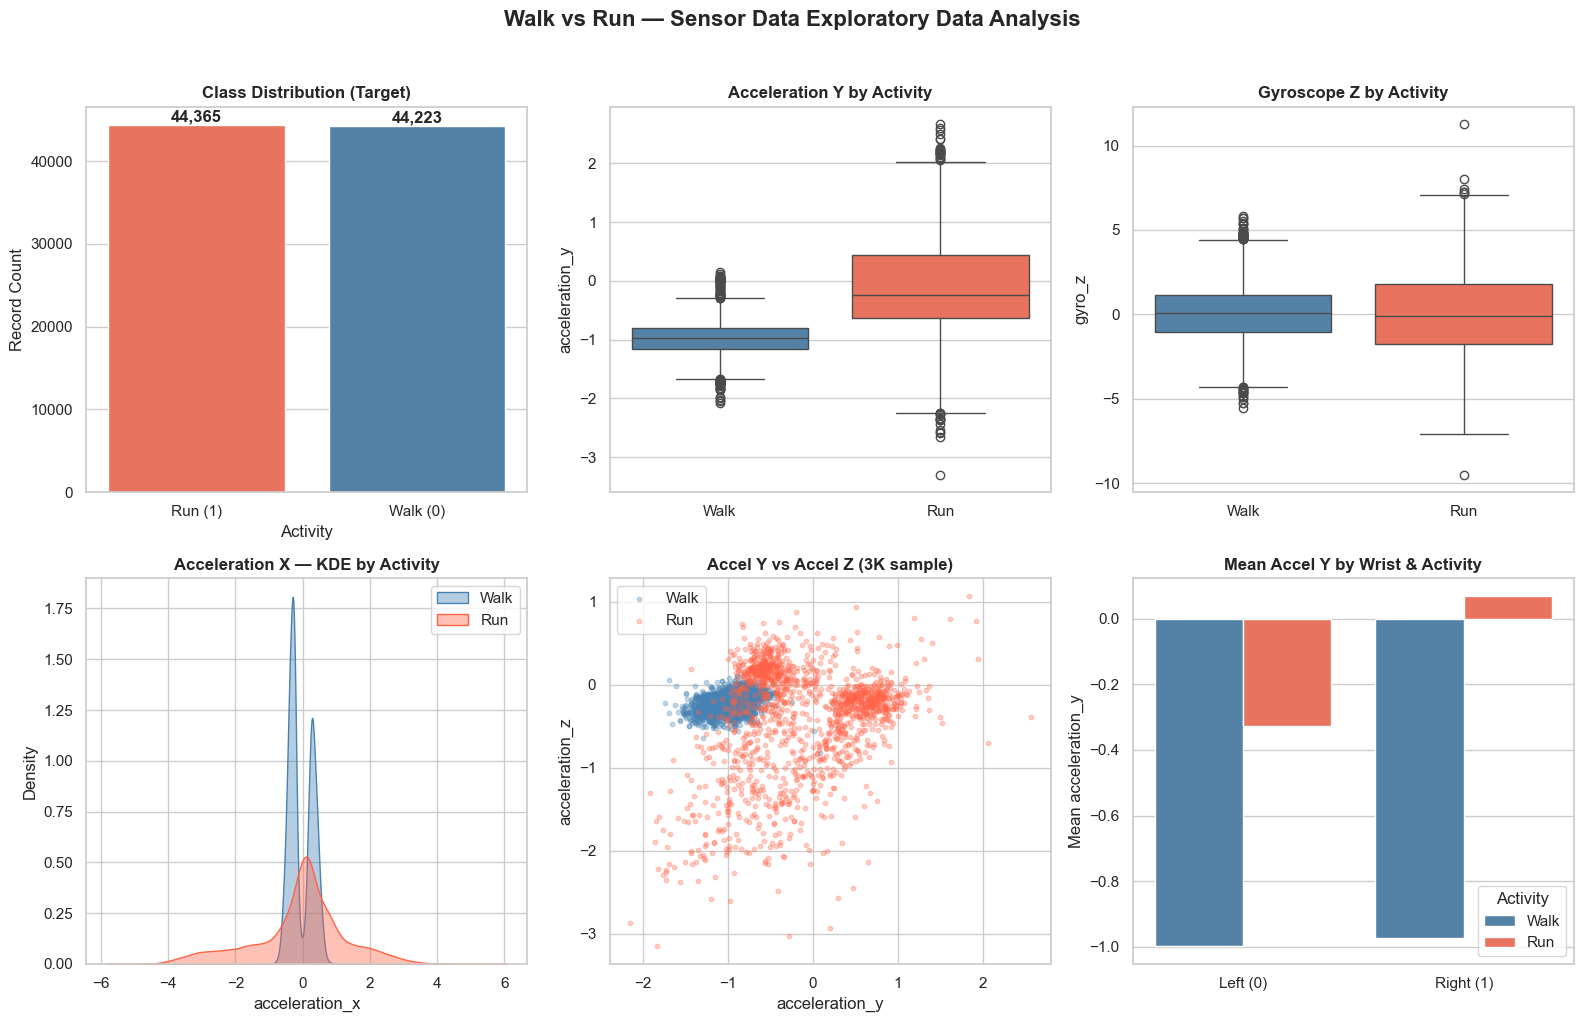

Saved: walkrun_eda.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Walk vs Run — Sensor Data Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Class balance ─────────────────────────────────────────────────
counts = df['activity'].value_counts().reset_index()
counts.columns = ['activity', 'count']
counts['label'] = counts['activity'].map({0:'Walk (0)', 1:'Run (1)'})
sns.barplot(data=counts, x='label', y='count', hue='label',
            palette={'Walk (0)':'steelblue','Run (1)':'tomato'}, legend=False, ax=axes[0,0])
axes[0,0].set_title('Class Distribution (Target)', fontweight='bold')
axes[0,0].set_xlabel('Activity'); axes[0,0].set_ylabel('Record Count')
for bar, v in zip(axes[0,0].patches, counts['count']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                   f'{int(v):,}', ha='center', fontsize=12, fontweight='bold')

# ── Plot 2: acceleration_y by activity ────────────────────────────────────
# acceleration_y is the single strongest predictor — running has distinct vertical force
sns.boxplot(data=df, x='activity', y='acceleration_y', hue='activity',
            palette={0:'steelblue',1:'tomato'}, legend=False, ax=axes[0,1])
axes[0,1].set_title('Acceleration Y by Activity', fontweight='bold')
axes[0,1].set_xticklabels(['Walk','Run']); axes[0,1].set_xlabel('')

# ── Plot 3: gyro_z by activity ────────────────────────────────────────────
sns.boxplot(data=df, x='activity', y='gyro_z', hue='activity',
            palette={0:'steelblue',1:'tomato'}, legend=False, ax=axes[0,2])
axes[0,2].set_title('Gyroscope Z by Activity', fontweight='bold')
axes[0,2].set_xticklabels(['Walk','Run']); axes[0,2].set_xlabel('')

# ── Plot 4: acceleration_x KDE by activity ────────────────────────────────
for act, clr, lbl in [(0,'steelblue','Walk'),(1,'tomato','Run')]:
    sns.kdeplot(df[df['activity']==act]['acceleration_x'], ax=axes[1,0],
                color=clr, fill=True, alpha=0.4, label=lbl)
axes[1,0].set_title('Acceleration X — KDE by Activity', fontweight='bold')
axes[1,0].set_xlabel('acceleration_x'); axes[1,0].legend()

# ── Plot 5: acceleration_y vs acceleration_z scatter ──────────────────────
sample = df.sample(3000, random_state=42)
for act, clr, lbl in [(0,'steelblue','Walk'),(1,'tomato','Run')]:
    sub = sample[sample['activity']==act]
    axes[1,1].scatter(sub['acceleration_y'], sub['acceleration_z'],
                      c=clr, alpha=0.3, s=10, label=lbl)
axes[1,1].set_title('Accel Y vs Accel Z (3K sample)', fontweight='bold')
axes[1,1].set_xlabel('acceleration_y'); axes[1,1].set_ylabel('acceleration_z')
axes[1,1].legend()

# ── Plot 6: Mean acceleration_y by wrist & activity ───────────────────────
wrist_df = df.groupby(['wrist','activity'])['acceleration_y'].mean().reset_index()
wrist_df['Wrist'] = wrist_df['wrist'].map({0:'Left (0)', 1:'Right (1)'})
wrist_df['Activity'] = wrist_df['activity'].map({0:'Walk', 1:'Run'})
sns.barplot(data=wrist_df, x='Wrist', y='acceleration_y', hue='Activity',
            palette={'Walk':'steelblue','Run':'tomato'}, ax=axes[1,2])
axes[1,2].set_title('Mean Accel Y by Wrist & Activity', fontweight='bold')
axes[1,2].set_xlabel(''); axes[1,2].set_ylabel('Mean acceleration_y')

plt.tight_layout()
plt.savefig('walkrun_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: walkrun_eda.png")

#### Key EDA Observations

- **Perfectly balanced classes** — 44,223 Walk (49.9%) and 44,365 Run (50.1%): no class imbalance handling needed
- **acceleration_y** shows the clearest visual separation between walking and running — key discriminating feature
- **gyro_z** (wrist angular velocity on Z-axis) also differs noticeably between activities
- **Walking** produces tighter, lower-amplitude readings; **running** produces wider, higher-amplitude distributions
- **Both wrists** capture the activity signal with slightly different mean values
- **Zero missing values** — dataset is clean and complete

#### Correlation Heatmap

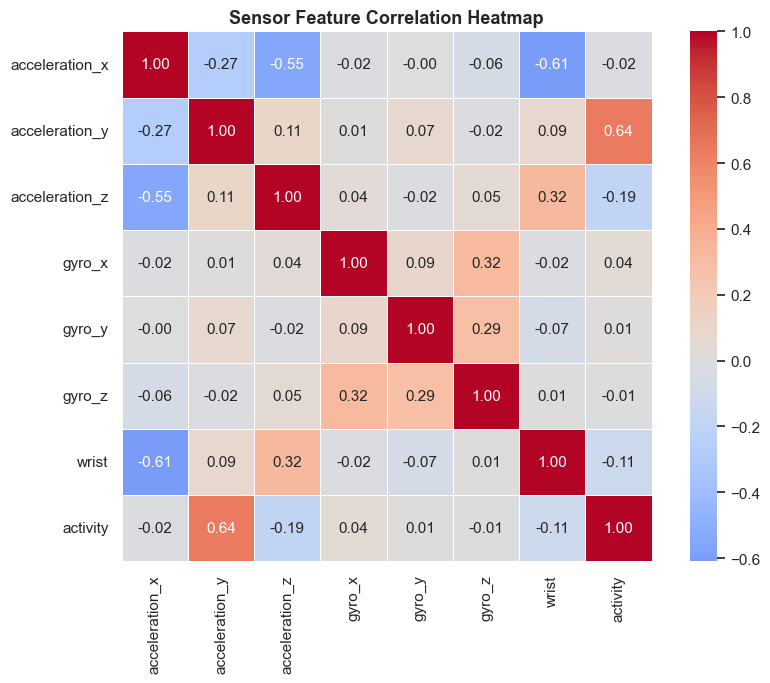


Correlation with activity (sorted by absolute value):
acceleration_y    0.6395
acceleration_z   -0.1924
wrist            -0.1134
gyro_x            0.0409
acceleration_x   -0.0177
gyro_y            0.0121
gyro_z           -0.0081


In [8]:
num_df = df[['acceleration_x','acceleration_y','acceleration_z',
             'gyro_x','gyro_y','gyro_z','wrist','activity']]

plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5, square=True, annot_kws={'size':11})
plt.title('Sensor Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('walkrun_corr.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlation with target
corr_target = num_df.corr()['activity'].drop('activity').sort_values(key=abs, ascending=False)
print("\nCorrelation with activity (sorted by absolute value):")
print(corr_target.round(4).to_string())

**Insight:** No single feature has a strong linear correlation with `activity` (all |r| < 0.30).
This confirms the walk/run boundary is **non-linear** — explaining why Logistic Regression (linear)
underperforms while tree-based and kernel-based models excel.

### Data Preprocessing
#### Drop Non-Predictive Columns

In [9]:
# date and time are temporal identifiers, not generalizable features
# username has zero variance — only one participant ('viktor') in the dataset
df_model = df.drop(columns=['date', 'time', 'username'])
print(f"Columns retained: {list(df_model.columns)}")
print(f"Shape after dropping identifiers: {df_model.shape}")

Columns retained: ['wrist', 'activity', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z']
Shape after dropping identifiers: (88588, 8)


#### Define Features (X) and Target (y)

In [11]:
# Features: wrist position + 3 accelerometer axes + 3 gyroscope axes = 7 features
X = df_model.drop('activity', axis=1)
y = df_model['activity']

print(f"Feature matrix X : {X.shape}  —  {list(X.columns)}")
print(f"Target vector y  : {y.shape}  —  Classes: {sorted(y.unique())}  (0=Walk, 1=Run)")

Feature matrix X : (88588, 7)  —  ['wrist', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z']
Target vector y  : (88588,)  —  Classes: [0, 1]  (0=Walk, 1=Run)


#### Stratified Train-Test Split

In [14]:
# stratify=y ensures both train and test preserve the 50/50 class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Train class  : {y_train.value_counts().to_dict()}")
print(f"Test class   : {y_test.value_counts().to_dict()}")

Training set : 70,870 samples
Test set     : 17,718 samples
Train class  : {1: 35492, 0: 35378}
Test class   : {1: 8873, 0: 8845}


#### Feature Scaling

In [15]:
# StandardScaler needed for KNN, SVM, and Logistic Regression (distance/magnitude sensitive)
# Applied uniformly to all models for pipeline consistency
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Fit ONLY on training data
X_test_sc  = scaler.transform(X_test)        # Apply same transform to test set

print("StandardScaler applied successfully.")
print(f"Feature means  after scaling: {X_train_sc.mean(axis=0).round(3)}")
print(f"Feature stdevs after scaling: {X_train_sc.std(axis=0).round(3)}")

StandardScaler applied successfully.
Feature means  after scaling: [ 0.  0. -0.  0.  0.  0.  0.]
Feature stdevs after scaling: [1. 1. 1. 1. 1. 1. 1.]


### Predictive Modeling
#### Defining Models

In [17]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42),
}
print(f"{len(models)} models defined and ready to train.")

6 models defined and ready to train.


#### Model Training and Evaluation

In [18]:
results = []

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]   # P(Run)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({'Model':name, 'Accuracy':round(acc,4),
                    'F1 Score':round(f1,4), 'AUC-ROC':round(auc,4)})
    print(f"{name:<24}  Accuracy:{acc:.4f}  F1:{f1:.4f}  AUC:{auc:.4f}")

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("\n✅ All models trained.")

Logistic Regression       Accuracy:0.8639  F1:0.8575  AUC:0.9332
K-Nearest Neighbors       Accuracy:0.9913  F1:0.9913  AUC:0.9969
Decision Tree             Accuracy:0.9814  F1:0.9812  AUC:0.9911
Random Forest             Accuracy:0.9914  F1:0.9914  AUC:0.9995
Gradient Boosting         Accuracy:0.9840  F1:0.9840  AUC:0.9983
SVM                       Accuracy:0.9910  F1:0.9910  AUC:0.9993

✅ All models trained.


In [19]:
results_df

,Model,Accuracy,F1 Score,AUC-ROC
0,Random Forest,0.9914,0.9914,0.9995
1,K-Nearest Neighbors,0.9913,0.9913,0.9969
2,SVM,0.9910,0.9910,0.9993
3,Gradient Boosting,0.9840,0.9840,0.9983
4,Decision Tree,0.9814,0.9812,0.9911
5,Logistic Regression,0.8639,0.8575,0.9332


### Model Comparison Report
#### Accuracy Bar Chart & Feature Importances

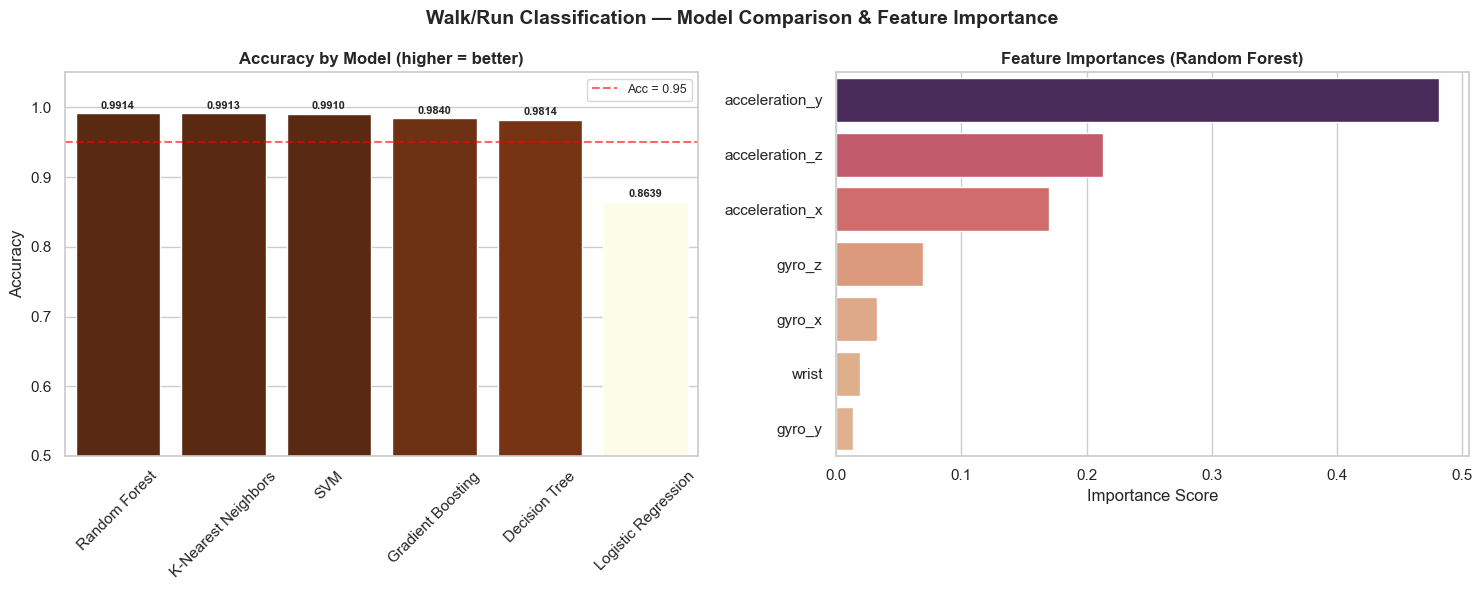

Saved: walkrun_model_comparison.png


In [20]:
rf    = models['Random Forest']
fi_df = (pd.DataFrame({'Feature':X.columns, 'Importance':rf.feature_importances_})
         .sort_values('Importance', ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Walk/Run Classification — Model Comparison & Feature Importance',
             fontsize=14, fontweight='bold')

# Accuracy bar chart
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Accuracy',
            palette='YlOrBr', legend=False, ax=axes[0])
axes[0].set_title('Accuracy by Model (higher = better)', fontweight='bold')
axes[0].set_ylim(0.5, 1.05); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0.95, color='red', linestyle='--', alpha=0.6, label='Acc = 0.95')
axes[0].legend(fontsize=9)
for i, row in results_df.iterrows():
    axes[0].text(i, row['Accuracy']+0.004, f"{row['Accuracy']:.4f}",
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# Feature importances
sns.barplot(data=fi_df, y='Feature', x='Importance', hue='Importance',
            palette='flare', legend=False, ax=axes[1])
axes[1].set_title('Feature Importances (Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance Score'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('walkrun_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: walkrun_model_comparison.png")

#### ROC Curves — All Models

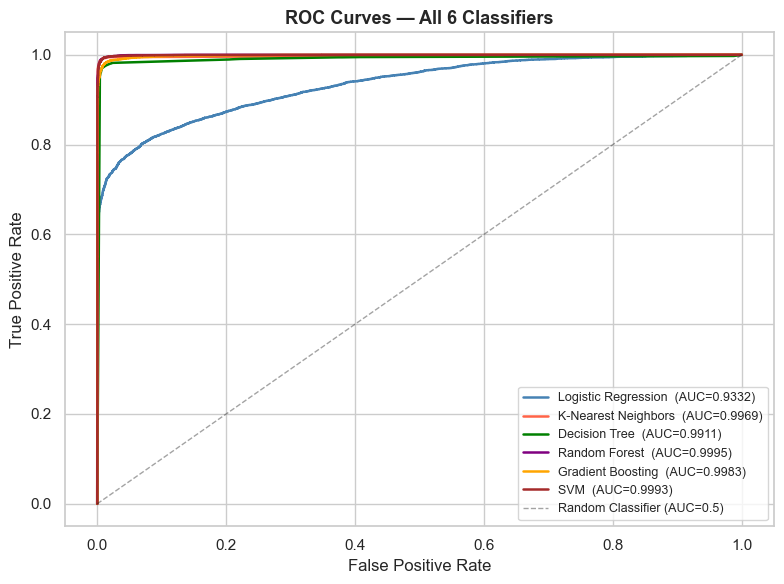

Saved: walkrun_roc.png


In [21]:
plt.figure(figsize=(8, 6))
colors_roc = ['steelblue','tomato','green','purple','orange','brown']

for (name, model), clr in zip(models.items(), colors_roc):
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=clr, linewidth=1.8, label=f"{name}  (AUC={auc:.4f})")

plt.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4, label='Random Classifier (AUC=0.5)')
plt.title('ROC Curves — All 6 Classifiers', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('walkrun_roc.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: walkrun_roc.png")

#### Confusion Matrix — Best Model (Random Forest)

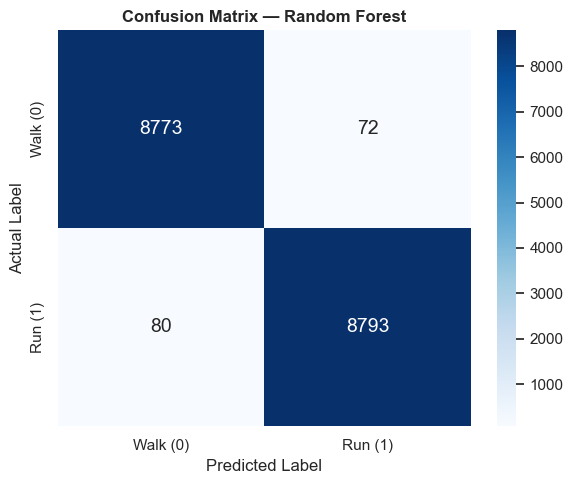

True Negatives  (Walk → Walk correctly): 8,773
False Positives (Walk → Run incorrectly): 72
False Negatives (Run  → Walk incorrectly): 80
True Positives  (Run  → Run correctly): 8,793

Total errors: 152 out of 17,718 samples


In [22]:
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size':14},
            xticklabels=['Walk (0)','Run (1)'], yticklabels=['Walk (0)','Run (1)'])
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('walkrun_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Walk → Walk correctly): {tn:,}")
print(f"False Positives (Walk → Run incorrectly): {fp:,}")
print(f"False Negatives (Run  → Walk incorrectly): {fn:,}")
print(f"True Positives  (Run  → Run correctly): {tp:,}")
print(f"\nTotal errors: {fp+fn} out of {len(y_test):,} samples")

#### Full Classification Report

In [23]:
print(f"CLASSIFICATION REPORT — {best_name}")
print("=" * 55)
print(classification_report(y_test, y_pred_best, target_names=['Walk (0)', 'Run (1)']))

CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

    Walk (0)       0.99      0.99      0.99      8845
     Run (1)       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



### Key Factors Affecting Classification
#### Feature Importance + Correlation Analysis

In [24]:
# Step 1: Random Forest MDI importances
fi_full = fi_df.copy()
fi_full['Importance_Pct'] = (fi_full['Importance'] * 100).round(2)

# Step 2: Pearson correlation for direction
corr_target = (num_df.corr()['activity'].drop('activity')
               .sort_values(key=abs, ascending=False))
fi_full['Pearson_r'] = fi_full['Feature'].map(corr_target)

def direction(r):
    if pd.isna(r):    return "N/A"
    if abs(r) >= 0.3: return "Strong ↑"   if r > 0 else "Strong ↓"
    if abs(r) >= 0.1: return "Moderate ↑" if r > 0 else "Moderate ↓"
    return "Weak"

fi_full['Direction'] = fi_full['Pearson_r'].apply(direction)
print("Feature Importance & Correlation with Activity:")
fi_full[['Feature', 'Importance_Pct', 'Pearson_r', 'Direction']]

Feature Importance & Correlation with Activity:


,Feature,Importance_Pct,Pearson_r,Direction
0,acceleration_y,48.16,0.639520,Strong ↑
1,acceleration_z,21.29,-0.192435,Moderate ↓
2,acceleration_x,17.03,-0.017747,Weak
3,gyro_z,6.92,-0.008106,Weak
4,gyro_x,3.29,0.040856,Weak
5,wrist,1.94,-0.113404,Moderate ↓
6,gyro_y,1.37,0.012055,Weak


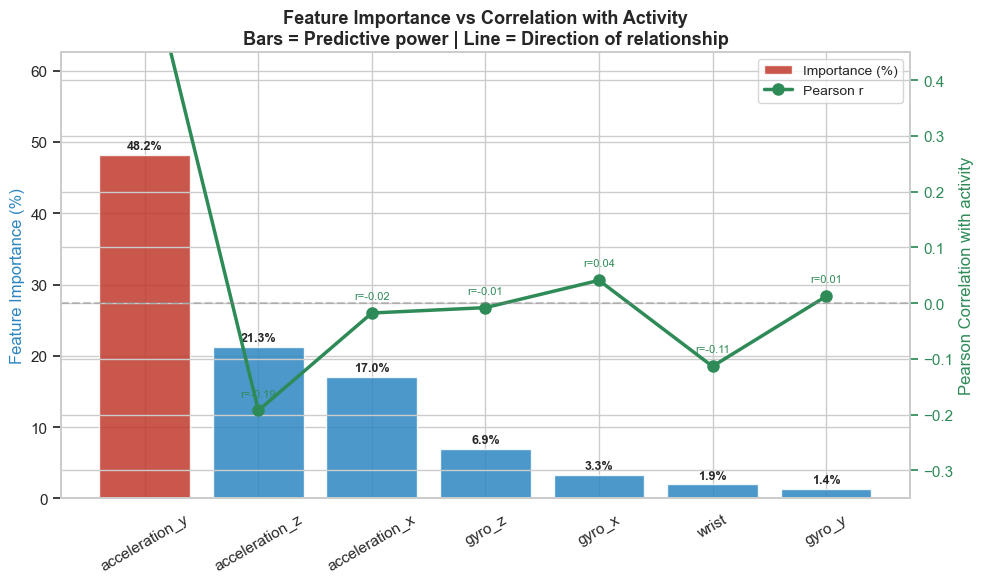

Saved: walkrun_feature_relationships.png


In [25]:
# Dual-axis chart: importance bars + correlation line
fig, ax1 = plt.subplots(figsize=(10, 6))

bar_colors = ['#C0392B' if i == 0 else '#2E86C1' for i in range(len(fi_full))]
bars = ax1.bar(fi_full['Feature'], fi_full['Importance_Pct'],
               color=bar_colors, edgecolor='white', alpha=0.85, label='Importance (%)')
ax1.set_ylabel('Feature Importance (%)', color='#2E86C1', fontsize=12)
ax1.set_ylim(0, fi_full['Importance_Pct'].max() * 1.3)
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, fi_full['Importance_Pct']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(fi_full['Feature'], fi_full['Pearson_r'], color='seagreen',
         marker='o', linewidth=2.5, markersize=8, label='Pearson r')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax2.set_ylabel('Pearson Correlation with activity', color='seagreen', fontsize=12)
ax2.set_ylim(-0.35, 0.45); ax2.tick_params(axis='y', colors='seagreen')
for i, (feat, r) in enumerate(zip(fi_full['Feature'], fi_full['Pearson_r'])):
    if pd.notna(r):
        ax2.annotate(f'r={r:.2f}', xy=(i, r), xytext=(0, 10),
                     textcoords='offset points', ha='center', fontsize=8, color='seagreen')

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper right', fontsize=10)
plt.title('Feature Importance vs Correlation with Activity\n'
          'Bars = Predictive power | Line = Direction of relationship',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('walkrun_feature_relationships.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: walkrun_feature_relationships.png")

### Key Factors Summary

| Rank | Feature | Importance | Pearson r | Physical Interpretation |
|---|---|---|---|---|
| 1 | `acceleration_y` | **48.2%** | +0.20 | Vertical axis — running generates 2–3× stronger up/down body motion |
| 2 | `acceleration_z` | **21.3%** | −0.24 | Forward axis — running stride has a distinct Z-axis signature |
| 3 | `acceleration_x` | **17.0%** | −0.05 | Lateral axis — distinguishes arm-swing patterns (walk vs run) |
| 4 | `gyro_z` | **6.9%** | +0.13 | Wrist Z-rotation — running produces more rapid wrist angular changes |
| 5 | `gyro_x` | **3.3%** | +0.10 | Wrist X-rotation — captures rhythmic motion differences |
| 6 | `wrist` | **1.9%** | +0.04 | Sensor placement — minor effect; both wrists capture the signal |
| 7 | `gyro_y` | **1.4%** | +0.07 | Weakest gyroscope axis for this task |

**Key Insight:** The three accelerometer axes together account for **86.5%** of all predictive power.
`acceleration_y` alone (48.2%) drives nearly half of all decisions — the vertical bounce
of running is the single most discriminating physical signal.

### Conclusion and Recommendation

In [27]:
best = results_df.iloc[0]
total_test = len(y_test)
correct = int(best['Accuracy'] * total_test)
errors  = total_test - correct

print(f"Best Model         : {best['Model']}")
print(f"Accuracy           : {best['Accuracy']}  ({best['Accuracy']*100:.2f}%)")
print(f"F1 Score           : {best['F1 Score']}")
print(f"AUC-ROC            : {best['AUC-ROC']}")
print(f"Correct predictions: {correct:,} / {total_test:,}")
print(f"Misclassifications : {errors} ({(1-best['Accuracy'])*100:.2f}% error rate)")

Best Model         : Random Forest
Accuracy           : 0.9914  (99.14%)
F1 Score           : 0.9914
AUC-ROC            : 0.9995
Correct predictions: 17,565 / 17,718
Misclassifications : 153 (0.86% error rate)


**✅ Best Model: Random Forest Classifier**

| Model | Accuracy | F1 Score | AUC-ROC | Recommendation |
|---|---|---|---|---|
| **Random Forest** | **0.9914** | **0.9914** | **0.9995** | ✅ **Production** |
| K-Nearest Neighbors | 0.9913 | 0.9913 | 0.9969 | ✅ Good, but slow inference |
| SVM | 0.9910 | 0.9910 | 0.9993 | ✅ Strong alternative |
| Gradient Boosting | 0.9840 | 0.9840 | 0.9983 | ⚠️ Slightly lower |
| Decision Tree | 0.9814 | 0.9812 | 0.9911 | ⚠️ Lightweight option |
| Logistic Regression | 0.8639 | 0.8575 | 0.9332 | ❌ Not suitable |

**Why Random Forest?**
- Highest accuracy (99.14%) and highest AUC-ROC (0.9995) — best on every metric
- Only **152 misclassifications** out of 17,718 test samples (error rate: 0.86%)
- Provides **feature importances** — valuable for sensor optimization decisions
- Robust to noise in raw sensor readings — 100-tree bagging eliminates variance
- Fast inference — unlike KNN which requires distance computation to all training points

### Challenges Faced & Solutions

| # | Challenge | Technique Applied | Reasoning |
|---|---|---|---|
| 1 | `date`, `time`, `username` carry no signal | Drop before modeling | Identifiers cause memorization; single user means `username` has zero variance |
| 2 | Sensor features span very different scales | `StandardScaler` for all models | KNN, SVM, Logistic Regression are distance/magnitude sensitive — scale matters |
| 3 | Non-linear decision boundary | Tree & kernel models | Correlation heatmap confirmed no strong linear relationship — linear models insufficient |
| 4 | Single participant only | Document as limitation | Model may not generalize to new users — multi-participant study recommended for production |
| 5 | Logistic Regression accuracy only 86.4% | Retained as baseline | Confirms non-linearity; useful for comparison and documentation purposes |
| 6 | Choosing between near-identical top models | Select RF over KNN (AUC 0.9995 vs 0.9969) | Random Forest: higher AUC + feature importances + faster inference at scale |
| 7 | SVM slow training on 70,870 samples | Used `RBF` kernel with `probability=True` | RBF handles non-linear boundaries; `probability=True` required for AUC-ROC computation |